# Day 24: Trust-Region 2D Projections
## BoT-IoT | Day-23 FROZEN Checkpoint | Capped Test + Zero-Day

Hilbert-space geometry of MAQT prototypes $\rho_c$ and sample states $\rho(x)$ projected to 2D.

## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import time
import json

In [2]:
from scripts.constants import DEFAULT_NOISE_RATE, DEFAULT_SEED
from scripts.data import capped_sample, load_split, to_angles
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.utils import get_torch_device, to_np_y
from scripts.logging import write_history_log
from scripts.hilbert import (
    encode_density_matrices,
    pairwise_trace_distance_matrix,
    fidelity_to_prototypes_matrix,
    mds_2d_from_distances,
    pca_2d,
)

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060


## Config

In [4]:
NOTEBOOK_NAME = "24.trust-region-2d_bot-iot"
DAY23_NOTEBOOK = "23.maqt-FROZEN-feat-prototypes_bot-iot"

dataset = "BoT-IoT"
target_col = "label_multiclass"
data_path = f"data/FROZEN/{dataset}"
frozen_feat_path = "team-artifacts/teamC_week3_FROZEN_handoff.json"

# visualization caps (default.mixed is expensive)
MAX_PER_CLASS = 100        # known test samples per class
MAX_ZERODAY = 40           # zero-day points on the figure
ENCODE_BATCH_SIZE = 8      # safe on ~6GB GPUs
SEED = DEFAULT_SEED

torch.manual_seed(SEED)
np.random.seed(SEED)

## Load Day-23 FROZEN Checkpoint

Reuse $\theta^\star$, prototypes, and the train-fitted scaler / PCA / angle bounds from Day-23.

In [5]:
device = get_torch_device()
out_dir = Path("models/prototypes") / dataset
ckpt_path = out_dir / f"{DAY23_NOTEBOOK}-checkpoint.pt"
assert ckpt_path.exists(), f"missing checkpoint: {ckpt_path}"

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

theta_star = ckpt["theta"]
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)

prototypes = {int(k): v for k, v in ckpt["prototypes"].items()}
class_names = list(ckpt["class_names"])
num_classes = int(ckpt["num_classes"])
num_qubits = int(ckpt["num_qubits"])
num_layers = int(ckpt["num_layers"])
noise_rate = float(ckpt.get("noise_rate", DEFAULT_NOISE_RATE))

FEATURE_COLS = list(ckpt.get("feature_cols") or json.loads(Path(frozen_feat_path).read_text())["frozen_subsets"][dataset]["features"])
scaler = ckpt["scaler"]
pca = ckpt.get("pca")
USE_PCA = bool(ckpt.get("use_pca", pca is not None))
x_min = np.asarray(ckpt["angle_x_min"])
x_max = np.asarray(ckpt["angle_x_max"])
angle_max = float(ckpt.get("angle_max", np.pi))
k95 = int(ckpt.get("k95", num_qubits))

print(f"loaded: {ckpt_path}")
print(f"qubits={num_qubits} | layers={num_layers} | classes={num_classes} | noise_p={noise_rate}")
print(f"USE_PCA={USE_PCA} | k95={k95} | feature_cols={len(FEATURE_COLS)}")
print(f"theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

loaded: models/prototypes/BoT-IoT/23.maqt-FROZEN-feat-prototypes_bot-iot-checkpoint.pt
qubits=5 | layers=2 | classes=4 | noise_p=0.01
USE_PCA=True | k95=5 | feature_cols=10
theta shape=(2, 5, 3) | prototypes=4


## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$$
x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)
$$

In [6]:
dev = create_quantum_device(num_qubits)
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

theta_star = theta_star.to(device)
if not isinstance(theta_star, torch.nn.Parameter):
    theta_star = torch.nn.Parameter(theta_star)
prototypes = {int(k): v.to(device) for k, v in prototypes.items()}

print("forward circuit ready")
print(f"device={device}")

forward circuit ready
device=cuda


## Load Team A FROZEN Dataset (Test + Zero-Day)

In [7]:
# load raw FROZEN splits (same features as Day-23)
X_test_full, y_test_full, _, df_test = load_split(
    data_path, "test", target_col, categories=class_names,
    csv=True, selected_cols=FEATURE_COLS, return_df=True,
)
X_zero_full, y_zero_full, _, df_zero = load_split(
    data_path, "zeroday", target_col,
    csv=True, selected_cols=FEATURE_COLS, return_df=True,
)

print(f"test full : {X_test_full.shape}")
print(f"zeroday   : {X_zero_full.shape}")

test full : (18591, 10)
zeroday   : (683, 10)


## Cap Data Subset for Visualization

In [8]:
X_known_raw, y_known = capped_sample(X_test_full, y_test_full, MAX_PER_CLASS, seed=SEED)

rng = np.random.default_rng(SEED)
n_zero = min(MAX_ZERODAY, len(X_zero_full))
z_idx = rng.choice(len(X_zero_full), size=n_zero, replace=False)
X_zero_raw = X_zero_full[z_idx]
y_zero = np.full(n_zero, -1, dtype=int)  # sentinel: zero-day

# raw -> scale -> optional pca -> [0, pi] using Day-23 train bounds
pca_for_angles = pca if USE_PCA else None
X_known = to_angles(X_known_raw, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max)
X_zero = to_angles(X_zero_raw, scaler, x_min, x_max, pca=pca_for_angles, angle_max=angle_max)

print(f"known vis : {X_known.shape} ({len(np.unique(y_known))} classes)")
print(f"zeroday   : {X_zero.shape}")
print(f"angles via Day-23 pipeline | USE_PCA={USE_PCA}")

known vis : (400, 5) (4 classes)
zeroday   : (40, 5)
angles via Day-23 pipeline | USE_PCA=True


## Encode $\rho(x)$ + Stack Prototypes

Post-channel states from the same circuit / preprocess used at Day-23 train time.

In [9]:
t0 = time.time()
print("encoding known samples...")
rho_known = encode_density_matrices(
    X_known, theta_star, forward_circuit, device=device, batch_size=ENCODE_BATCH_SIZE,
)
print(f"  rho_known {tuple(rho_known.shape)}  ({time.time()-t0:.1f}s)")

t1 = time.time()
print("encoding zero-day samples...")
rho_zero = encode_density_matrices(
    X_zero, theta_star, forward_circuit, device=device, batch_size=ENCODE_BATCH_SIZE,
)
print(f"  rho_zero  {tuple(rho_zero.shape)}  ({time.time()-t1:.1f}s)")

proto_ids = sorted(prototypes)
rho_proto = torch.stack([prototypes[c].detach().cpu() for c in proto_ids], dim=0)
print(f"  rho_proto {tuple(rho_proto.shape)}")

# stacked order: known | zero-day | prototypes
rho_all = torch.cat([rho_known, rho_zero, rho_proto], dim=0)
n_known, n_zero, n_proto = len(rho_known), len(rho_zero), len(rho_proto)
labels_all = np.concatenate([to_np_y(y_known).astype(int), y_zero, np.asarray(proto_ids, dtype=int)])
kind_all = np.array(
    ["known"] * n_known + ["zeroday"] * n_zero + ["prototype"] * n_proto
)
print(f"total states for embedding: {len(rho_all)}")

encoding known samples...
  rho_known (400, 32, 32)  (2.3s)
encoding zero-day samples...
  rho_zero  (40, 32, 32)  (0.2s)
  rho_proto (4, 32, 32)
total states for embedding: 444


## Primary Figure: MDS on $D_{\mathrm{tr}}$

Embed all states with classical MDS on pairwise trace distances so the 2D layout reflects Hilbert-space geometry between samples and prototypes.

In [10]:
t2 = time.time()
print("computing pairwise D_tr ...")
D_tr = pairwise_trace_distance_matrix(rho_all)
print(f"  distance matrix {D_tr.shape}  ({time.time()-t2:.1f}s)")

t3 = time.time()
Z_mds = mds_2d_from_distances(D_tr, random_state=SEED)
print(f"  MDS done  ({time.time()-t3:.1f}s)")

Z_known = Z_mds[:n_known]
Z_zero = Z_mds[n_known:n_known + n_zero]
Z_proto = Z_mds[n_known + n_zero:]

computing pairwise D_tr ...
  distance matrix (444, 444)  (4.2s)
  MDS done  (0.6s)


saved figure: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/BoT-IoT/24.trust-region-2d_bot-iot-mds.png


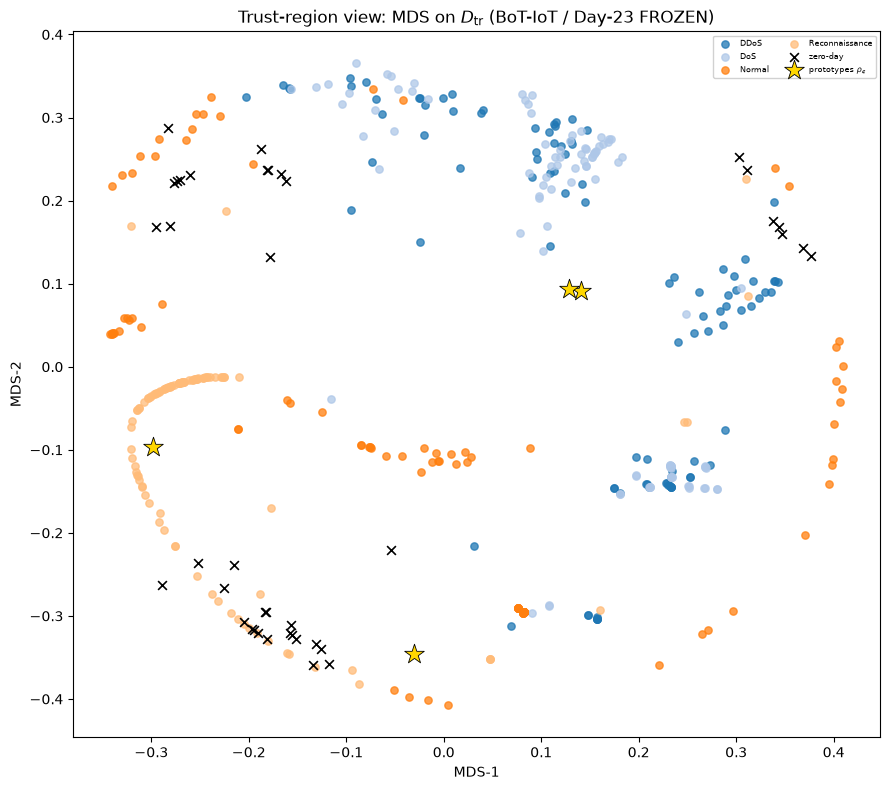

In [11]:
fig, ax = plt.subplots(figsize=(9, 8))

# known samples colored by class
cmap = plt.colormaps["tab20"].resampled(max(num_classes, 20))
y_k = to_np_y(y_known).astype(int)
for c in sorted(np.unique(y_k)):
    m = y_k == c
    ax.scatter(
        Z_known[m, 0], Z_known[m, 1],
        s=28, alpha=0.75, color=cmap(c % 20),
        label=class_names[c] if c < len(class_names) else str(c),
    )

# zero-day
ax.scatter(
    Z_zero[:, 0], Z_zero[:, 1],
    s=40, marker="x", c="black", linewidths=1.2, label="zero-day", zorder=4,
)

# prototypes
ax.scatter(
    Z_proto[:, 0], Z_proto[:, 1],
    s=220, marker="*", c="gold", edgecolors="black", linewidths=0.6,
    label=r"prototypes $\rho_c$", zorder=5,
)

ax.set_title(r"Trust-region view: MDS on $D_{\mathrm{tr}}$ "+f"({dataset} / Day-23 FROZEN)")
ax.set_xlabel("MDS-1")
ax.set_ylabel("MDS-2")
ax.legend(fontsize=6, ncol=2, loc="best", framealpha=0.9)
plt.tight_layout()

fig_path = out_dir / f"{NOTEBOOK_NAME}-mds.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
print("saved figure:", fig_path.resolve())
plt.show()

## Aux Figure: Fidelity $\rightarrow$ Prototype PCA

Represent each state by its fidelity vector $(F(\rho,\rho_c))_c$ to all class prototypes, then project that vector to 2D with PCA for a fast alternative view of the same geometry.

saved figure: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/BoT-IoT/24.trust-region-2d_bot-iot-pca.png


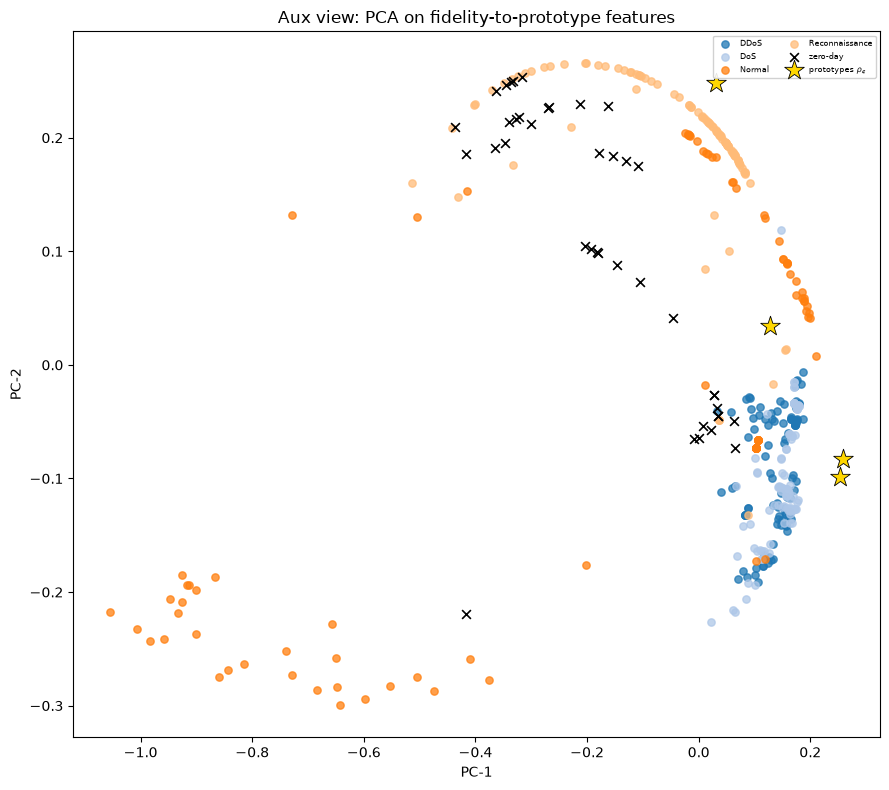

In [12]:
_, feats = fidelity_to_prototypes_matrix(rho_all, {c: prototypes[c].cpu() for c in proto_ids})
Z_pca = pca_2d(feats)

Z_known_p = Z_pca[:n_known]
Z_zero_p = Z_pca[n_known:n_known + n_zero]
Z_proto_p = Z_pca[n_known + n_zero:]

fig, ax = plt.subplots(figsize=(9, 8))
for c in sorted(np.unique(y_k)):
    m = y_k == c
    ax.scatter(
        Z_known_p[m, 0], Z_known_p[m, 1],
        s=28, alpha=0.75, color=cmap(c % 20),
        label=class_names[c] if c < len(class_names) else str(c),
    )
ax.scatter(Z_zero_p[:, 0], Z_zero_p[:, 1], s=40, marker="x", c="black", linewidths=1.2, label="zero-day", zorder=4)
ax.scatter(
    Z_proto_p[:, 0], Z_proto_p[:, 1],
    s=220, marker="*", c="gold", edgecolors="black", linewidths=0.6,
    label=r"prototypes $\rho_c$", zorder=5,
)
ax.set_title("Aux view: PCA on fidelity-to-prototype features")
ax.set_xlabel("PC-1"); ax.set_ylabel("PC-2")
ax.legend(fontsize=6, ncol=2, loc="best", framealpha=0.9)
plt.tight_layout()

fig_pca_path = out_dir / f"{NOTEBOOK_NAME}-pca.png"
fig.savefig(fig_pca_path, dpi=160, bbox_inches="tight")
print("saved figure:", fig_pca_path.resolve())
plt.show()

## Logging

In [13]:
coords_path = out_dir / f"{NOTEBOOK_NAME}-coords.npz"
np.savez(
    coords_path,
    Z_mds=Z_mds,
    Z_pca=Z_pca,
    D_tr=D_tr,
    labels=labels_all,
    kind=kind_all,
    class_names=np.asarray(class_names),
    proto_ids=np.asarray(proto_ids),
    n_known=n_known,
    n_zero=n_zero,
    n_proto=n_proto,
    max_per_class=MAX_PER_CLASS,
    max_zeroday=MAX_ZERODAY,
    checkpoint=str(ckpt_path),
    use_pca=bool(USE_PCA),
    k95=int(k95),
)
print("saved coords:", coords_path.resolve())

artifact = {
    "notebook": NOTEBOOK_NAME,
    "checkpoint": str(ckpt_path),
    "dataset": dataset,
    "data_path": data_path,
    "feature_cols": list(FEATURE_COLS),
    "use_pca": bool(USE_PCA),
    "k95": int(k95),
    "num_qubits": num_qubits,
    "num_layers": num_layers,
    "noise_rate": noise_rate,
    "n_known": int(n_known),
    "n_zero": int(n_zero),
    "n_proto": int(n_proto),
    "max_per_class": MAX_PER_CLASS,
    "max_zeroday": MAX_ZERODAY,
    "figure_mds": str(fig_path),
    "figure_pca": str(fig_pca_path),
    "coords": str(coords_path),
}
torch.save(artifact, out_dir / f"{NOTEBOOK_NAME}-artifact.pt")
print("published:", (out_dir / f"{NOTEBOOK_NAME}-artifact.pt").resolve())

log_path = write_history_log(
    {},
    NOTEBOOK_NAME,
    extra=artifact,
    log_dir="logs",
)
print("wrote", log_path.resolve())

saved coords: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/BoT-IoT/24.trust-region-2d_bot-iot-coords.npz
published: /home/lawun330/Desktop/quantum-sentinel/models/prototypes/BoT-IoT/24.trust-region-2d_bot-iot-artifact.pt
wrote /home/lawun330/Desktop/quantum-sentinel/logs/24.trust-region-2d_bot-iot.log
